In [1]:
import torch
import numpy as np
import gymnasium as gym

import torch
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from PIL import Image
from pyvirtualdisplay import Display
import gymnasium_robotics
import metaworld
gym.register_envs(gymnasium_robotics)

import os
os.environ['MUJOCO_GL'] = 'egl'
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../src')))
from src.data_gen.gen_fetch import name_to_env, env_to_aspace, process_image, meta_world_envs, metaworld_cam_name
from src.utils import set_seed

# disp = Display(visible=0, size=(480, 480))
# disp.start()
# os.environ["DISPLAY"] = "99"
rand_seed=123
device = torch.device(f"cuda:{1}" if torch.cuda.is_available() else "cpu")
from pathlib import Path
os.chdir(Path(os.getcwd()).parent.parent)

In [2]:
import matplotlib as mpl
# Configure Matplotlib to use LaTeX for text rendering
plt.rcParams['text.usetex'] = False
plt.rcParams['pdf.fonttype'] = 42  # Ensures TrueType fonts are used
plt.rcParams['ps.fonttype'] = 42   # Ensures TrueType fonts for PostScript output
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Didot'] + plt.rcParams['font.serif']

mpl.rcParams['lines.linewidth'] = 5
mpl.rcParams['lines.markersize'] = 10
mpl.rcParams['lines.markeredgewidth'] = 1
mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['figure.titlesize'] = 36
mpl.rcParams['figure.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 32
# mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.titlepad'] = 5
mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['xtick.major.pad'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['ytick.major.pad'] = 3
mpl.rcParams['figure.subplot.hspace'] = 0.85
mpl.rcParams["axes.labelpad"] = 5

bw_props = dict(linestyle='-', linewidth=2.5, color='black')
boxplot_kwargs = dict(
    vert=True,
    patch_artist=True,
    widths=0.5,
    whis=[0, 100],
    showfliers=False,
    medianprops=bw_props,
    boxprops=bw_props,
    capprops=bw_props,
    whiskerprops=bw_props,
    flierprops=dict(linestyle='', markersize=10, markeredgewidth=2, color='black'),
    showmeans=False,
    meanline=True
)

In [2]:
environments = ['faucet']
paths = {env: {'pixel': [], 'dynamics': [], 'random': []} for env in environments}
actions = {env: {'pixel': [], 'dynamics': [], 'random': []} for env in environments}
for i in range(100, 101):
    # for policy, objective in zip(['eig', 'maxdyn', 'random'], ['pixel', 'dynamics', 'random']):
    for policy, objective in zip(['eig', 'maxdyn'], ['pixel', 'dynamics']):
        for env in environments:
            path = "runs/{env}/{env}_{objective}_{i}/".format(env=env, objective=objective, i=i)
            paths[env][objective].append(path)
            action_path = "runs/{env}/{env}_{objective}_{i}/training_states.pt".format(env=env, objective=objective, i=i)
            actions[env][objective].append(action_path)

In [3]:
# environments = ['door', 'coffee', 'drawer', 'button', 'faucet']
objectives = ['pixel', 'dynamics'] #, 'random']
objective_labels = {'random': 'Random', 'pixel': 'Pixel', 'dynamics': 'Dynamics'}
colors = {'random': '#ff8080', 'pixel': '#304674', 'dynamics': '#957dadff'}

#TODO: have to redo loss for coffee and button dynamics?

runs/faucet/faucet_pixel_100/
Env:  faucet med 508.2372 25 367.2715301513672 75 689.7610931396484
runs/faucet/faucet_dynamics_100/
Env:  faucet med 1186.0375 25 749.2347106933594 75 3375.1240234375


/tmp/ipykernel_1716952/1867322795.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(np.linspace(0, len(rew), 6, dtype=int))
/tmp/ipykernel_1716952/1867322795.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(np.linspace(0, len(rew), 6, dtype=int))


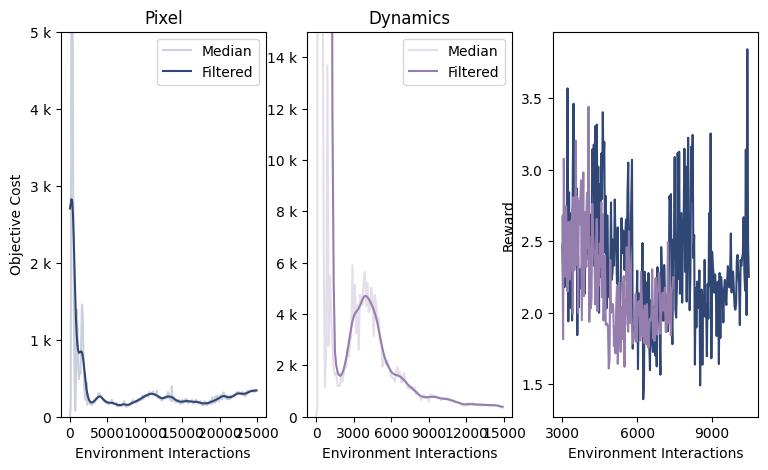

In [4]:
from matplotlib.ticker import EngFormatter
from scipy.ndimage import gaussian_filter1d

plot_every = 100
start_at = 0
for env, path_all in paths.items():
    # if env != 'door':
    #     continue
    fig, ax = plt.subplots(1, 3, figsize=(9, 5))
    # fig.subplots_adjust(wspace=0.2)  # Increase horizontal spacing
    for i, objective in enumerate(objectives): # Exclude 'random' for this plot
        path = path_all[objective][0]
        print(path)
        try:
            costs = torch.load(os.path.join(path, 'costs_rollout_500.pt')).cpu().numpy()  # Shape: (num_rollouts, rollout_length)
            rew = torch.load(os.path.join(path, 'training_states.pt')).cpu().numpy()[:, -5]  # Shape: (num_rollouts, rollout_length)
            # print(f"Loaded costs from {path}, shape: {np.median(costs, axis=1).shape}")
            median = np.median(costs[start_at::plot_every, :], axis=1)
            twenty_five = np.percentile(costs[start_at::plot_every, :], 25, axis=1)
            seventy_five = np.percentile(costs[start_at::plot_every, :], 75, axis=1)
            medians_smooth = gaussian_filter1d(median, sigma=3)
            p25_smooth = gaussian_filter1d(twenty_five, sigma=3)
            p75_smooth = gaussian_filter1d(seventy_five, sigma=3)
            ptp = np.ptp(costs[start_at::plot_every, :], axis=1)
            print("Env: ", env, "med", np.median(ptp), "25", np.percentile(ptp, 25), "75", np.percentile(ptp, 75))
            ax[i].plot(median, label='Median', color=colors[objective], alpha=0.25)
            ax[i].plot(medians_smooth, label='Filtered', color=colors[objective], alpha=1.0)
            # ax[i].fill_between(range(len(medians_smooth)), p25_smooth, p75_smooth, color=colors[objective], alpha=0.2)
            ax[i].set_xlabel('Environment Interactions') # , fontsize=24)
            ax[i].set_xticks(ticks=np.linspace(0, len(median), 6))
            ax[i].set_xticklabels(np.linspace(0, len(costs), 6, dtype=int))
            # ax[i].set_title(f'{env.capitalize()} - {objective_labels[objective].capitalize()}', fontsize=28)
            ax[i].set_title(f'{objective_labels[objective].capitalize()}') #, fontsize=28)
            if i == 0:
                ax[i].set_ylim([0, 5000])
                ax[i].set_ylabel('Objective Cost') # , fontsize=24)
            elif i == 1:
                ax[i].set_ylim([0, 15000])
            ax[i].yaxis.set_major_formatter(EngFormatter(unit='', places=0))
            ax[i].legend() #fontsize=18)
            # mean_costs = np.mean(costs, axis=0)  # Mean over rollouts
            # all_costs.append(mean_costs)
        except Exception as e:
            print(f"Error loading costs from {path}: {e}")
        ax[2].plot(rew[start_at::plot_every], label=objective_labels[objective], color=colors[objective])
        ax[2].set_xlabel('Environment Interactions') # , fontsize=24)
        ax[2].set_ylabel('Reward') # , fontsize=24)
        # ax[2].set_xticks(ticks=np.linspace(0, len(rew), 6))
        ax[2].set_xticklabels(np.linspace(0, len(rew), 6, dtype=int))
    plt.show()
    # avg_costs = np.mean(np.array(all_costs), axis=0)  # Mean over different runs
    # plt.plot(avg_costs, label=objective_labels[objective], color=colors[objective])

faucet pixel


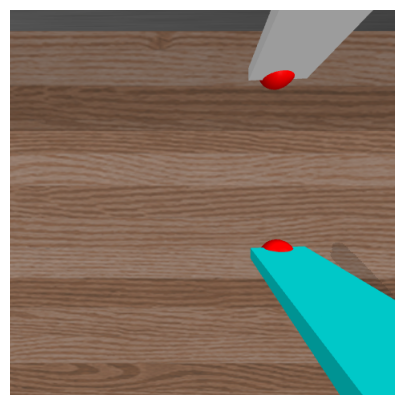

In [7]:
for env, path_all in paths.items():
    for i, objective in enumerate(objectives[:-1]): # Exclude 'random' for this plot
        print(env, objective)
        # fig, ax = plt.subplots(1, 6, figsize=(25, 5))
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        path = path_all[objective][0]
        chkpts = []
        for p in os.listdir(path):
            if p.endswith('.pt'):
                chkpts.append(os.path.join(path, p))
        env_instance = gym.make('Meta-World/MT1', env_name=name_to_env[env], render_mode='rgb_array', camera_name='gripperPOV')
        obs, _ = env_instance.reset()
        ax.imshow(process_image(env_instance.render(), env, downscale=False))
        # states: list of 3 tensors/arrays; cols: [x, y, z, gripper, x_obj, y_obj, z_obj, reward, xdot, ydot, zdot, gripper_vel]
        # actions_data = torch.load(actions[env][objective][0]).cpu().numpy()[:, -4:]
        # for i in range(5):
        #     for act in actions_data[i*50*100:i*50*100+100]:
        #         for _ in range(4):
        #             obs, rew, done, trunc, _ = env_instance.step(act)
        #     ax[1+i].imshow(process_image(env_instance.render(), env, downscale=False))
        #     obs, _ = env_instance.reset()
        # for axs in ax:
        #     axs.axis('off')
        ax.axis('off')
        plt.show()

        # costs = torch.load(os.path.join(path, 'costs_rollout.pt')).cpu().numpy()  # Shape: (num_rollouts, rollout_length)

In [88]:
# TODO: load a video in from a given file path, and plot selected frames from it
def load_video_frames(video_path, frame_indices):
    import cv2
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    for idx in frame_indices:
        if idx < total_frames:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame)
    cap.release()
    return frames

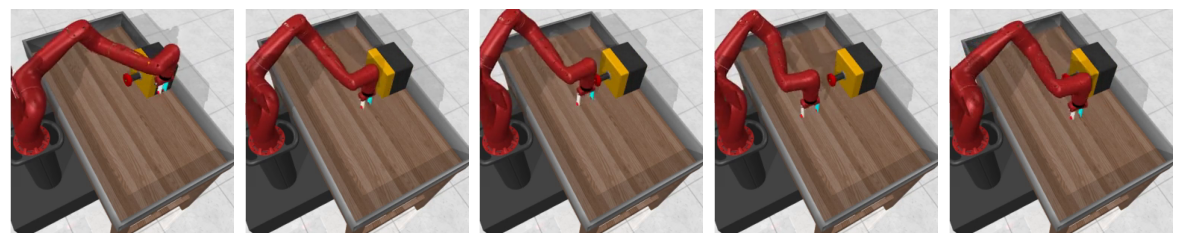

In [ ]:
video_path = 'src/data_gen/contact/videos/button_pixel_22/button_0.mp4'
frame_indices = [780, 790, 800, 810, 820]
frames = load_video_frames(video_path, frame_indices)
fig, ax = plt.subplots(1, len(frames), figsize=(3*len(frames), 5))
plt.subplots_adjust(wspace=0.05)
for i, f in enumerate(frames):
    ax[i].imshow(f[50:-50, 50:-50, :])
    ax[i].axis('off')
plt.show()
fig.savefig('src/data_gen/shortcomings/peekaboo_button.png', bbox_inches='tight', dpi=200)

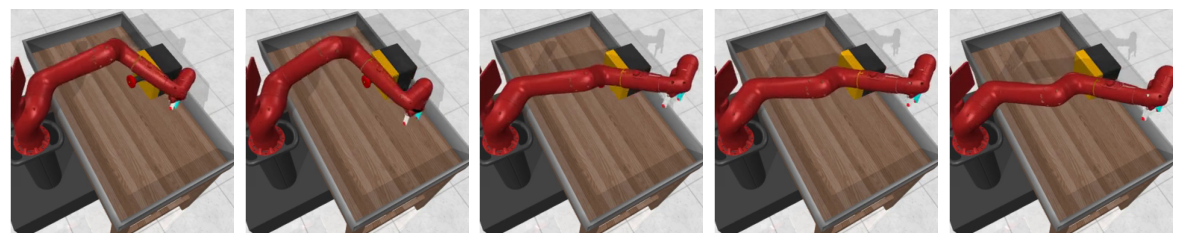

In [ ]:
video_path = 'src/data_gen/contact/videos/button_dynamics_22/button_0.mp4'
frame_indices = [770, 780, 790, 800, 810]
frames = load_video_frames(video_path, frame_indices)
fig, ax = plt.subplots(1, len(frames), figsize=(3*len(frames), 5))
plt.subplots_adjust(wspace=0.05)
for i, f in enumerate(frames):
    ax[i].imshow(f[50:-50, 50:-50, :])
    ax[i].axis('off')
plt.show()
fig.savefig('src/data_gen/shortcomings/joint_lims_button.png', bbox_inches='tight', dpi=200)

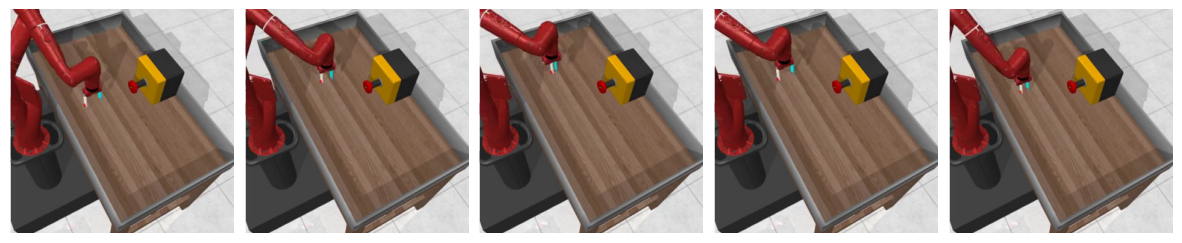

In [90]:
video_path = 'src/data_gen/contact/videos/button_pixel_22/button_6.mp4'
frame_indices = [0, 10, 20, 30, 40]
frames = load_video_frames(video_path, frame_indices)
fig, ax = plt.subplots(1, len(frames), figsize=(3*len(frames), 5))
plt.subplots_adjust(wspace=0.05)
for i, f in enumerate(frames):
    ax[i].imshow(f[50:-50, 50:-50, :])
    ax[i].axis('off')
plt.show()
fig.savefig('src/data_gen/shortcomings/shadow_chasing.png', bbox_inches='tight', dpi=200)

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import numpy as np
from pathlib import Path
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import binned_statistic_2d
from PIL import Image
import os
os.chdir(Path(os.getcwd()).parent.parent)  # Change to project root
# import metaworld
# import gymnasium as gym
# os.environ['MUJOCO_GL'] = 'egl'

In [2]:
all_envs = ['button', 'coffee', 'door', 'drawer', 'faucet']
paths = {env: {'pixel': [], 'dynamics': [], 'random': []} for env in all_envs}
for i in range(20, 23):
    for policy, objective in zip(['eig', 'maxdyn', 'random'], ['pixel', 'dynamics', 'random']):
        for env in all_envs:
            # if env == 'coffee' and objective == 'pixel':
            #     config = "runs/{env}/{env}_{objective}_{i}/config.yaml".format(env=env, objective=objective, i=5)
            # else:
            path = "src/data_gen/contact/videos/{env}_{objective}_{i}/".format(env=env, objective=objective, i=i)
            paths[env][objective].append(path)

heatmap seeds:
button: seed_21, pixel=0, dynamics = 3
coffee: seed 21, pixel=0, seed 20, dynamics = 4
door: seed 20, pixel=8, dynamics=0
drawer: seed 20, pixel=8, seed 21, dynamics=7
faucet: seed 20, pixel=8, seed 22, dynamics=3

In [ ]:
from PIL import Image
PROJECT_ROOT = Path("/home/ayush/Desktop/tutorials/rl_latent/E2C/")
env_name = 'coffee'
# pixel is 0:3, dynamics is 3:6, random is 6:9
seeds = [1, 0, 1] # 20 is 0, 21 is 1, 22 is 2
indices = [0, 3, 2]
states = []
for policy, seed, idx in zip(['pixel', 'dynamics', 'random'], seeds, indices):
    states.append(torch.load(PROJECT_ROOT / paths[env_name][policy][seed] / Path(env_name + f'_{idx}.pt'))[:100])
    print(PROJECT_ROOT / paths[env_name][policy][seed] / Path(env_name + f'_{idx}.pt'), states[-1].shape)


states_np = [s.cpu().numpy() if hasattr(s, "cpu") else np.asarray(s) for s in states]
pos_titles = [""]

# Add position titles with contact counts
for i in range(3):
    pos_titles.append(f"# Contacts: {np.count_nonzero(states_np[i][:, -1])}")

# Parameters
bins = 15
x_min, x_max = -0.45, 0.45
y_min, y_max = -0.25, 1.05

def hist2d_with_velocity(arr, bins):
    x, y = arr[:, 0], arr[:, 1]
    vx, vy, vz = arr[:, 8], arr[:, 9], arr[:, 10]
    vel = np.linalg.norm((vx, vy, vz), axis=0) / 4 / 3
    occ_pos, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[[x_min, x_max], [y_min, y_max]])
    occ_vel, _, _, _ = binned_statistic_2d(x, y, vel, bins=bins, range=[[x_min, x_max], [y_min, y_max]])
    
    xc = 0.5 * (xedges[:-1] + xedges[1:])
    yc = 0.5 * (yedges[:-1] + yedges[1:])
    return occ_pos, occ_vel, xc, yc, xedges, yedges

# Compute global min/max
all_occ_pos = []
for arr in states_np:
    occ_pos, occ_vel, _, _, xedges, yedges = hist2d_with_velocity(arr, bins)
    occ_pos_masked = np.where(occ_pos == 0, np.nan, occ_pos)
    all_occ_pos.append(occ_pos_masked)

pos_min = np.nanmin([np.nanmin(x) for x in all_occ_pos])
pos_max = np.nanmax([np.nanmax(x) for x in all_occ_pos])

plotly_font = dict(family="Didot, serif", size=20, color="black")
# Create figure with 4 columns (image + 3 heatmaps)
fig = make_subplots(rows=1, cols=4, horizontal_spacing=0.05,
                    subplot_titles=pos_titles)
fig_width = 1400

# Load background image
img = Image.open("src/data_gen/temp_figs/" + env_name + "_topdown.png")

# Column 1: Add background image
fig.add_layout_image(
    dict(
        source=img,
        xref="x1",
        yref="y1",
        x=x_min,
        y=y_max,
        sizex=x_max - x_min,
        sizey=y_max - y_min,
        sizing="stretch",
        opacity=1.0,
        layer="above"
    )
)

# Columns 2-4: Add heatmaps with background images
for col, arr in enumerate(states_np, start=2):
    occ_pos, occ_vel, xc, yc, xedges, yedges = hist2d_with_velocity(arr, bins)
    occ_pos = np.where(occ_pos == 0, np.nan, occ_pos)

    # Add heatmap
    fig.add_trace(
        go.Heatmap(
            x=xc, y=yc, z=occ_pos.T, colorscale="peach",
            zmin=pos_min, zmax=pos_max,
            colorbar=dict(len=0.8, y=0.5,
                            tickfont=dict(family="Didot, serif", size=14, color="black")),
            showscale=(col == 4)
        ),
        row=1, col=col
    )
    fig.add_annotation(
        x=1.045, y=0.935, xref="paper", yref="paper",
        text="Timesteps",
        showarrow=False,
        font=dict(family="Didot, serif", size=20, color="black"),
        xanchor="center", yanchor="middle"
    )
    
    # Add markers
    start_x, start_y = arr[0, 0], arr[0, 1]
    end_x, end_y = arr[-1, 0], arr[-1, 1]
    fig.add_trace(
        go.Scatter(
            x=[start_x], y=[start_y], mode="markers",
            marker=dict(size=16, color="red", symbol="circle"),
            name="start pos", showlegend=(col == 2)
        ),
        row=1, col=col
    )
    fig.add_trace(
        go.Scatter(
            x=[end_x], y=[end_y], mode="markers",
            marker=dict(size=16, color="green", symbol="circle"),
            name="end pos", showlegend=(col == 2)
        ),
        row=1, col=col
    )
    
    # Add background image with 50% opacity
    fig.add_layout_image(
        dict(
            source=img,
            xref=f"x{col}",
            yref=f"y{col}",
            x=x_min,
            y=y_max,
            sizex=x_max - x_min,
            sizey=y_max - y_min,
            sizing="stretch",
            opacity=0.7,
            layer="below"
        )
    )

# Update axes for column 1 (image only)
fig.update_xaxes(range=[x_min, x_max], showticklabels=False, showgrid=False, 
                 zeroline=False, row=1, col=1)
fig.update_yaxes(range=[y_min, y_max], showticklabels=False, showgrid=False, 
                 zeroline=False, row=1, col=1)

# Update axes for columns 2-4 (heatmaps)
for c in range(2, 5):
    fig.update_xaxes(range=[x_min, x_max], row=1, col=c,
                    tickvals=xedges, showgrid=True, gridcolor='rgba(0, 0, 0, 1)',
                    showticklabels=False,
                    title_font=dict(family="Didot, serif", size=20))
    fig.update_yaxes(range=[y_min, y_max], row=1, col=c,
                    tickvals=yedges, showgrid=True, gridcolor='rgba(0, 0, 0, 1)',
                    showticklabels=False,
                    title_font=dict(family="Didot, serif", size=20))

# Draw borders around each subplot
for c in range(1, 5):
    fig.update_xaxes(showline=True, linewidth=1, linecolor="black", 
                    mirror=True, zeroline=False, row=1, col=c)
    fig.update_yaxes(showline=True, linewidth=1, linecolor="black", 
                    mirror=True, zeroline=False, row=1, col=c)

# Update layout
fig.update_layout(
    height=450, width=fig_width, template="plotly_white",
    font=plotly_font,
    title=dict(
        text=f"<b>Coverage from Control Objectives</b>",
        x=0.5, xanchor="center",
        y=0.9, yanchor="bottom",
        font=dict(family="Didot, serif", size=42, color="black")
    ),
    margin=dict(l=50, r=120, t=120, b=20),
    hovermode=False,
    legend=dict(
        orientation="h",
        yanchor="top", y=-0.05,
        xanchor="center", x=0.5,
        font=dict(family="Didot, serif", size=20)
    ),
)
# Reduce spacing between columns - tighter spacing
fig['layout']['xaxis1']['domain'] = [0.0, 0.235]
fig['layout']['xaxis2']['domain'] = [0.255, 0.49]
fig['layout']['xaxis3']['domain'] = [0.51, 0.745]
fig['layout']['xaxis4']['domain'] = [0.765, 1.0]

# Add column titles
col_titles = ["<b>Top Down View</b>", "<b>Pixel Objective</b>", "<b>Dynamic Objective</b>", "<b>Random</b>"]
row_xs = [0.05, 0.375, 0.63, 0.935]
for i, text in enumerate(col_titles):
    fig.add_annotation(
        x=row_xs[i], y=1.2, xref="paper", yref="paper",
        text=text, showarrow=False,
        font=dict(family="Didot, serif", size=24, color="black"),
        align="center"
    )

# Nudge colorbars
for tr in fig.data:
    if isinstance(tr, go.Heatmap) and tr.colorbar:
        tr.update(colorbar=dict(x=1.02))

fig.show()
fig.write_image("src/data_gen/temp_figs/" + env_name + "_heatmap.png", width=fig_width, height=450)

/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/contact/videos/coffee_pixel_21/coffee_0.pt torch.Size([100, 13])
/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/contact/videos/coffee_dynamics_20/coffee_3.pt torch.Size([100, 13])
/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/contact/videos/coffee_random_21/coffee_2.pt torch.Size([100, 13])


heatmap seeds:
button: seed_21, pixel=0, dynamics = 3; random 22, 2
coffee: seed 21, pixel=0, seed 20, dynamics = 3; random 22, 2
door: seed 20, pixel=8, dynamics=0; random 22, 1
drawer: seed 20, pixel=8, seed 21, dynamics=7; random 22, 1
faucet: seed 20, pixel=8, seed 22, dynamics=3; random 22, 1

In [86]:
from PIL import Image
PROJECT_ROOT = Path("/home/ayush/Desktop/tutorials/rl_latent/E2C/")
env_name = 'faucet'
# pixel is 0:3, dynamics is 3:6, random is 6:9
seeds = [0, 1, 2] # 20 is 0, 21 is 1, 22 is 2
indices = [8, 3, 5]
states = []
for policy, seed, idx in zip(['pixel', 'dynamics', 'random'], seeds, indices):
    states.append(torch.load(PROJECT_ROOT / paths[env_name][policy][seed] / Path(env_name + f'_{idx}.pt'))[:100])
    print(PROJECT_ROOT / paths[env_name][policy][seed] / Path(env_name + f'_{idx}.pt'), states[-1].shape)


states_np = [s.cpu().numpy() if hasattr(s, "cpu") else np.asarray(s) for s in states]
pos_titles = [""]

# Add position titles with contact counts
for i in range(3):
    pos_titles.append(f"# Contacts: {np.count_nonzero(states_np[i][:, -1])}")

# Parameters
bins = 15
x_min, x_max = -0.45, 0.45
y_min, y_max = -0.15, 1.2

def hist2d_with_velocity(arr, bins):
    x, y = arr[:, 0], arr[:, 1]
    vx, vy, vz = arr[:, 8], arr[:, 9], arr[:, 10]
    vel = np.linalg.norm((vx, vy, vz), axis=0) / 4 / 3
    occ_pos, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[[x_min, x_max], [y_min, y_max]])
    occ_vel, _, _, _ = binned_statistic_2d(x, y, vel, bins=bins, range=[[x_min, x_max], [y_min, y_max]])
    
    xc = 0.5 * (xedges[:-1] + xedges[1:])
    yc = 0.5 * (yedges[:-1] + yedges[1:])
    return occ_pos, occ_vel, xc, yc, xedges, yedges

# Compute global min/max
all_occ_pos = []
for arr in states_np:
    occ_pos, occ_vel, _, _, xedges, yedges = hist2d_with_velocity(arr, bins)
    occ_pos_masked = np.where(occ_pos == 0, np.nan, occ_pos)
    all_occ_pos.append(occ_pos_masked)

pos_min = np.nanmin([np.nanmin(x) for x in all_occ_pos])
pos_max = np.nanmax([np.nanmax(x) for x in all_occ_pos])

plotly_font = dict(family="Didot, serif", size=20, color="black")

# Create figure with 4 rows (image + 3 heatmaps)
fig = make_subplots(rows=4, cols=1)
fig_height = 1450
fig_width = 450

# Load background image
img = Image.open("src/data_gen/temp_figs/" + env_name + "_topdown.png")

# Row 1: Add background image
fig.add_layout_image(
    dict(
        source=img,
        xref="x1",
        yref="y1",
        x=x_min,
        y=y_max,
        sizex=x_max - x_min,
        sizey=y_max - y_min,
        sizing="stretch",
        opacity=1.0,
        layer="above"
    )
)

# Rows 2-4: Add heatmaps with background images
for row, arr in enumerate(states_np, start=2):
    occ_pos, occ_vel, xc, yc, xedges, yedges = hist2d_with_velocity(arr, bins)
    occ_pos = np.where(occ_pos == 0, np.nan, occ_pos)

    # Add heatmap
    fig.add_trace(
        go.Heatmap(
            x=xc, y=yc, z=occ_pos.T, colorscale="peach",
            zmin=pos_min, zmax=pos_max,
            colorbar=dict(len=0.75, y=0.125, yanchor="bottom",
                            tickfont=dict(family="Didot, serif", size=20, color="black"),
                            tickvals=[5, 10, 15, 20, 25, 30, 35]),
            showscale=(row == 4)
        ),
        row=row, col=1
    )
    
    # Add markers
    start_x, start_y = arr[0, 0], arr[0, 1]
    end_x, end_y = arr[-1, 0], arr[-1, 1]
    fig.add_trace(
        go.Scatter(
            x=[start_x], y=[start_y], mode="markers",
            marker=dict(size=16, color="red", symbol="circle"),
            name="start pos", showlegend=(row == 1)
        ),
        row=row, col=1
    )
    fig.add_trace(
        go.Scatter(
            x=[end_x], y=[end_y], mode="markers",
            marker=dict(size=16, color="green", symbol="circle"),
            name="end pos", showlegend=(row == 1)
        ),
        row=row, col=1
    )
    
    # Add background image with 50% opacity
    fig.add_layout_image(
        dict(
            source=img,
            xref=f"x{row}",
            yref=f"y{row}",
            x=x_min,
            y=y_max,
            sizex=x_max - x_min,
            sizey=y_max - y_min,
            sizing="stretch",
            opacity=0.7,
            layer="below"
        )
    )

# Update axes for row 1 (image only)
fig.update_xaxes(range=[x_min, x_max], showticklabels=False, showgrid=False, 
                 zeroline=False, row=1, col=1)
fig.update_yaxes(range=[y_min, y_max], showticklabels=False, showgrid=False, 
                 zeroline=False, row=1, col=1)

# Update axes for rows 2-4 (heatmaps)
for r in range(2, 5):
    fig.update_xaxes(range=[x_min, x_max], row=r, col=1,
                    tickvals=xedges, showgrid=True, gridcolor='rgba(0, 0, 0, 1)',
                    showticklabels=False,
                    title_font=dict(family="Didot, serif", size=20))
    fig.update_yaxes(range=[y_min, y_max], row=r, col=1,
                    tickvals=yedges, showgrid=True, gridcolor='rgba(0, 0, 0, 1)',
                    showticklabels=False,
                    title_font=dict(family="Didot, serif", size=20))

# Draw borders around each subplot
for r in range(1, 5):
    fig.update_xaxes(showline=True, linewidth=1, linecolor="black", 
                    mirror=True, zeroline=False, row=r, col=1)
    fig.update_yaxes(showline=True, linewidth=1, linecolor="black", 
                    mirror=True, zeroline=False, row=r, col=1)

# Update layout
fig.update_layout(
    height=fig_height, width=fig_width, template="plotly_white",
    font=plotly_font,
    # title=dict(
    #     text=f"<b>Coverage from Control Objectives</b>",
    #     x=0.5, xanchor="center",
    #     y=0.99, yanchor="top",
    #     font=dict(family="Didot, serif", size=42, color="black")
    # ),
    margin=dict(l=50, r=50, t=20, b=0),
    hovermode=False,
    # legend=dict(
    #     orientation="h",
    #     yanchor="bottom", y=-0.02,
    #     xanchor="center", x=0.5,
    #     font=dict(family="Didot, serif", size=20)
    # ),
)

# Reduce spacing between rows - tighter spacing
fig['layout']['yaxis1']['domain'] = [0.8, 1.0]
fig['layout']['yaxis2']['domain'] = [0.55, 0.76]
fig['layout']['yaxis3']['domain'] = [0.3, 0.51]
fig['layout']['yaxis4']['domain'] = [0.05, 0.26]

# Add row titles
row_titles = ["<b>Top Down View</b>", "<b>Pixel Objective</b>", "<b>Dynamic Objective</b>", "<b>Random</b>"]
row_ys = [0.90, 0.65, 0.4, 0.15]
for i, text in enumerate(row_titles):
    fig.add_annotation(
        x=-0.075, y=row_ys[i], xref="paper", yref="paper",
        text=text, showarrow=False,
        font=dict(family="Didot, serif", size=26, color="black"),
        textangle=-90,
        xanchor="center", yanchor="middle"
    )

row_ys = [1.0, 0.7875, 0.53, 0.265]
for i, text in enumerate(pos_titles):
    fig.add_annotation(
        x=0.5, y=row_ys[i], xref="paper", yref="paper",
        text=text, showarrow=False,
        font=dict(family="Didot, serif", size=24, color="black"),
        align="center"
    )

# Colorbar annotation
fig.add_annotation(
    x=0.5, y=0.035, xref="paper", yref="paper",
    text="Timesteps",
    showarrow=False,
    font=dict(family="Didot, serif", size=24, color="black"),
    xanchor="center", yanchor="middle"
)

# Nudge colorbars
for tr in fig.data:
    if isinstance(tr, go.Heatmap) and tr.colorbar:
        tr.update(colorbar=dict(x=0.5, y=-0.025, orientation="h"))

fig.show()
fig.write_image("src/data_gen/temp_figs/" + env_name + "_heatmap_vertical.png", width=fig_width, height=fig_height)

/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/contact/videos/faucet_pixel_20/faucet_8.pt torch.Size([100, 13])
/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/contact/videos/faucet_dynamics_21/faucet_3.pt torch.Size([100, 13])
/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/contact/videos/faucet_random_22/faucet_5.pt torch.Size([100, 13])


In [162]:
import matplotlib as mpl
# Configure Matplotlib to use LaTeX for text rendering
plt.rcParams['text.usetex'] = False
plt.rcParams['pdf.fonttype'] = 42  # Ensures TrueType fonts are used
plt.rcParams['ps.fonttype'] = 42   # Ensures TrueType fonts for PostScript output
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Didot'] + plt.rcParams['font.serif']

mpl.rcParams['lines.linewidth'] = 5
mpl.rcParams['lines.markersize'] = 10
mpl.rcParams['lines.markeredgewidth'] = 1
mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['figure.titlesize'] = 36
mpl.rcParams['figure.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 32
# mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.titlepad'] = 5
mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['xtick.major.pad'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['ytick.major.pad'] = 3
mpl.rcParams['figure.subplot.hspace'] = 0.85
mpl.rcParams["axes.labelpad"] = 5

bw_props = dict(linestyle='-', linewidth=2.5, color='black')
boxplot_kwargs = dict(
    vert=True,
    patch_artist=True,
    widths=0.5,
    whis=[0, 100],
    showfliers=False,
    medianprops=bw_props,
    boxprops=bw_props,
    capprops=bw_props,
    whiskerprops=bw_props,
    flierprops=dict(linestyle='', markersize=10, markeredgewidth=2, color='black'),
    showmeans=False,
    meanline=True
)
base = mpl.cm.get_cmap("Greens")
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "Greens_trunc", base(np.linspace(0.5, 1.0, 256))  # raise 0.25 if still too light
)
norm = mpl.colors.Normalize(vmin=10, vmax=100, clip=True)

/tmp/ipykernel_3446496/3721995761.py:45: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



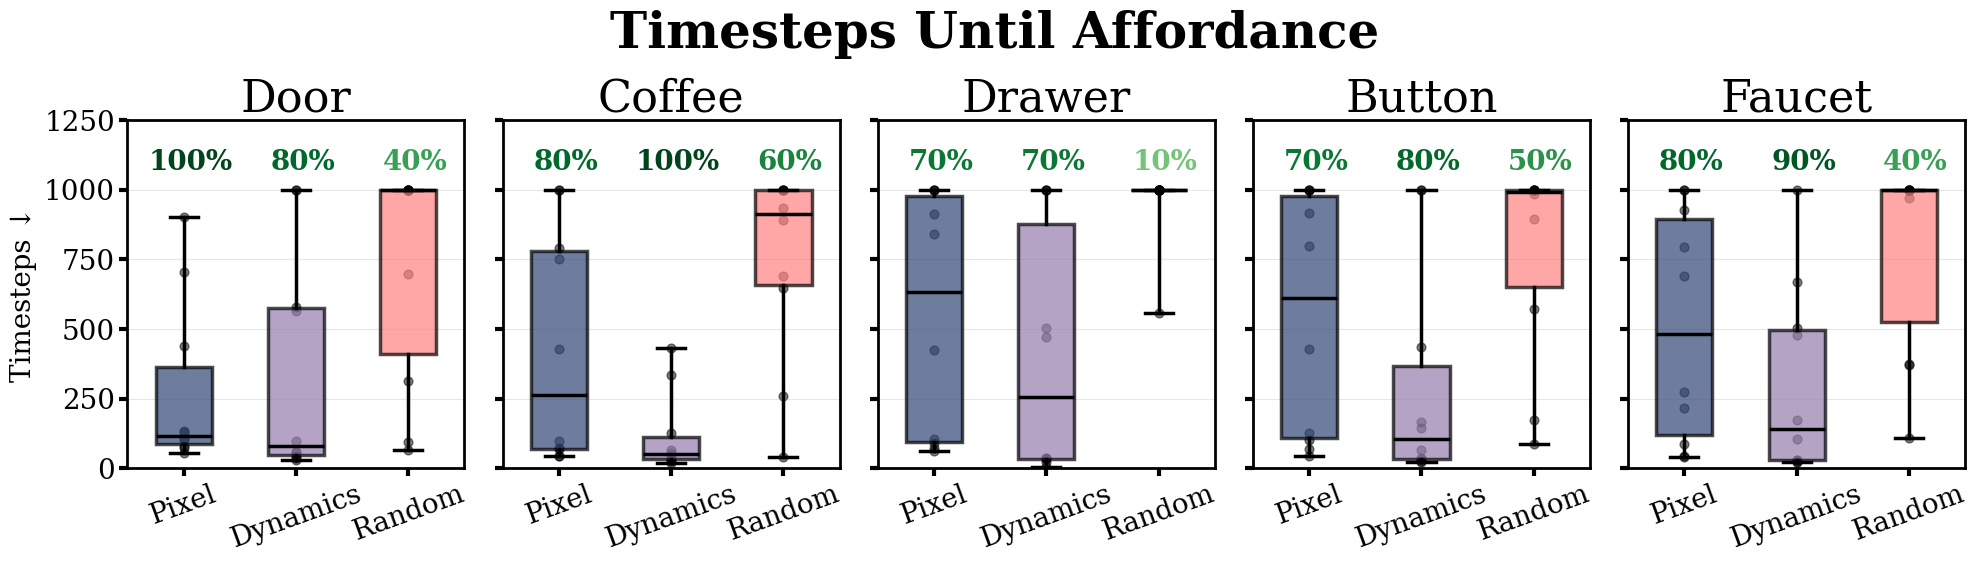

In [166]:
import json
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

with open(f"/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/contact/contacts_seed_22_keep.json", "r") as f:
    data_22 = json.load(f)

data = data_22.copy()

environments = ['door', 'coffee', 'drawer', 'button', 'faucet']
objectives = ['pixel', 'dynamics', 'random']
objective_labels = {'random': 'Random', 'pixel': 'Pixel', 'dynamics': 'Dynamics'}
colors = {'random': '#ff8080', 'pixel': '#304674', 'dynamics': '#957dadff'}

# Prepare data for plotting
plot_data = {env: {obj: data[env][obj+ "_affordance"] for obj in objectives} for env in environments}

fig, axes = plt.subplots(1, len(environments), figsize=(20, 6), sharey=True)

for idx, env in enumerate(environments):
    ax = axes[idx]
    parts = []

    for j, obj in enumerate(objectives):
        values = plot_data[env][obj]
        # Violin plot for each objective
        non_zero_values = [v for v in values if v > 0]
        scaled_values = []
        for v in values:
            if v == 0:
                scaled_values.append(1000)  # Use NaN for zero values to exclude them from the plot
            else:
                scaled_values.append(v)
        success = len(non_zero_values) / len(values) * 100

        # vp = ax.violinplot(
        #     scaled_values,
        #     positions=[j],
        #     showmeans=False,
        #     showmedians=True,
        #     showextrema=True,
        #     widths=0.8,
        #     bw_method=0.3, points=500
        # )
        # for pc in vp['bodies']:
        #     # # Get current vertices
        #     # vertices = pc.get_paths()[0].vertices
        #     # # Normalize x-coordinates to max_density
        #     # if len(scaled_values) > 1:
        #     #     kde = gaussian_kde(scaled_values, bw_method=0.3)
        #     #     local_max = np.max(kde(scaled_values))
        #     #     scale_factor = local_max / max_density
        #     #     # Scale width
        #     #     vertices[:, 0] = j + (vertices[:, 0] - j) * scale_factor
        #     #     pc.get_paths()[0].vertices = vertices

        #     pc.set_facecolor(colors[obj])
        #     pc.set_alpha(0.7)
        # for partname in ('cbars', 'cmedians', 'cmaxes', 'cmins'):
        #     vp[partname].set_edgecolor('black')
        #     vp[partname].set_linewidth(2)
        # parts.append(vp)
        bp = ax.boxplot(scaled_values,
                        vert=True, 
                        patch_artist=True, 
                        medianprops=bw_props, 
                        boxprops=dict(linestyle='-', linewidth=2.5, color='black'), 
                        capprops=bw_props, 
                        whiskerprops=bw_props, 
                        showfliers=False,
                        flierprops=dict(linestyle='', markersize=10, markeredgewidth=2, color='black'),
                        widths=0.5,
                        whis=[0, 100],
                        positions=[j],
                        showmeans=False,
                        # meanprops=mean_props,
                        meanline=True)

        for patch in bp["boxes"]:
            patch.set_facecolor(colors[obj])
            patch.set_alpha(0.7)
        ax.scatter(
            j * np.ones_like(values),
            scaled_values,
            alpha=0.5,
            color='black',
            s=40
        )
        # Add success percentage annotation above max value
        ax.text(j+0.06, 1050, f'{success:.0f}%', 
                ha='center', va='bottom', 
                color=cmap(norm(success)), fontsize=20, fontweight='bold')
    ax.set_xticks(range(len(objectives)))
    ax.set_xticklabels([objective_labels[obj] for obj in objectives], rotation=20)
    ax.set_title(env.capitalize())
    if idx == 0:
        ax.set_ylabel("Timesteps \u2193")
        ax.set_ylim([0, 1250])
    ax.grid(True, axis='y', alpha=0.3)

# Add a legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=colors[obj], label=objective_labels[obj], alpha=0.7) for obj in objectives]
# fig.legend(handles=legend_handles, loc='upper right') #, fontsize=14)

plt.suptitle("Timesteps Until Affordance", y=0.93) #, fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/temp_figs/tsteps_afford.png", bbox_inches='tight', dpi=200)
plt.show()